## Setup

In [7]:
import pandas as pd

from evaluation.plot_style import apply_plot_style
from models.llm.common import METRICS_DIR, DATA_DIR
from evaluation.llm.helpers import (
    load_metrics_from_dir,
    extract_model_metrics,
    plot_metrics_vs_prompt_token_count,
    build_prompt_configuration_table,
    compute_optimization_comparison_table,
    format_optimization_comparison_latex,
)
from evaluation.core import (
    load_train_test_data,
)

apply_plot_style()

## Load Configs

In [31]:
df_metrics, items, config_names = load_metrics_from_dir(METRICS_DIR)

Loaded 14 metric file(s) → 34 model result(s), 14 configuration(s)


## Prompt Table

In [32]:
df_table = build_prompt_configuration_table(df_metrics)

# Generate LaTeX table
latex_table = df_table.to_latex(
    index=False,
    escape=False,
    caption="Prompt Configuration Evaluation Results",
    label="tab:prompt_configs",
)
print(latex_table)

# Also display as formatted table for quick review
print("\n\nFormatted Table:")
print(df_table.to_string(index=False))

\begin{table}
\caption{Prompt Configuration Evaluation Results}
\label{tab:prompt_configs}
\begin{tabular}{rllllll}
\toprule
\textbf{#} & \textbf{Task Descr.} & \textbf{Examples} & \textbf{CoT} & \textbf{CORR} $\uparrow$ & \textbf{RMSE} $\downarrow$ & F1w \\
\midrule
1 & Short &  &  & 0.838 & 0.961 & 0.339 \\
2 & Short &  & zero-shot & 0.816 & 0.981 & 0.322 \\
3 & Short & ✓ &  & 0.840 & \textbf{0.953} & 0.462 \\
4 & Short & ✓ & zero-shot & 0.824 & 0.981 & 0.452 \\
5 & Expanded &  &  & 0.829 & 1.050 & 0.452 \\
6 & Expanded &  & zero-shot & 0.803 & 1.101 & 0.456 \\
7 & Expanded & ✓ &  & 0.837 & 1.041 & 0.447 \\
8 & Expanded & ✓ & zero-shot & 0.822 & 0.970 & \textbf{0.469} \\
9 & Expanded & ✓ & few-shot & 0.821 & 1.027 & 0.444 \\
10 & Full &  &  & 0.826 & 1.021 & 0.459 \\
11 & Full &  & zero-shot & 0.808 & 1.045 & 0.444 \\
12 & Full & ✓ &  & 0.835 & 1.049 & 0.463 \\
13 & Full & ✓ & zero-shot & 0.831 & 1.017 & 0.465 \\
14 & Full & ✓ & few-shot & \textbf{0.842} & 0.958 & 0.449 \\
\bottomrul

## Post-optimization Table

In [30]:
SELECTED_CONFIG_IDX = 0
SELECTED_MODEL_NAME = "Llama4-Scout-17b"

PRE_OPTIMIZATION_DIR = METRICS_DIR / "pre-optimization"

# Load pre-optimization metrics
pre_optim_metric_files = sorted(PRE_OPTIMIZATION_DIR.glob("*.json"))
print(f"Found {len(pre_optim_metric_files)} pre-optimization metric files")

pre_optim_metrics = []
for metric_file in pre_optim_metric_files:
    try:
        model_metrics = extract_model_metrics(metric_file)
        pre_optim_metrics.extend(model_metrics)
    except Exception as e:
        print(f"✗ Error processing {metric_file.name}: {e}")

df_pre_optim = pd.DataFrame(pre_optim_metrics)

# Pre-filter by selected configuration and train split only
config_name = config_names[SELECTED_CONFIG_IDX]
df_current_filtered = df_metrics[
    df_metrics["prompt_id"].str.startswith(config_name)
    & (df_metrics["dataset"] == "train")
].reset_index(drop=True)
df_pre_optim_filtered = df_pre_optim[
    df_pre_optim["prompt_id"].str.startswith("few-shot_no-cot_On-a-scale")
    & (df_pre_optim["dataset"] == "train")
].reset_index(drop=True)
print(df_current_filtered)
print(df_pre_optim_filtered)

# Compute comparison table
df_comparison_table = compute_optimization_comparison_table(
    df_current=df_current_filtered,
    df_pre_optim=df_pre_optim_filtered,
    selected_model_name=SELECTED_MODEL_NAME,
)

print(f"\nOptimization Comparison for Config {SELECTED_CONFIG_IDX}: {config_name}")
print("=" * 100)
print(df_comparison_table.round(4).to_string(index=False))

# Generate LaTeX table with colored deltas
latex_table = format_optimization_comparison_latex(df_comparison_table)

# Display the LaTeX table
print(latex_table)

Found 14 pre-optimization metric files
             model_name                                          prompt_id  \
0      Llama4-Scout-17b  few-shot_no-cot_On-a-scale_2026-03-06-18-49-16...   
1        Ministral3-14b  few-shot_no-cot_On-a-scale_2026-03-06-18-49-16...   
2            Gemma3-12b  few-shot_no-cot_On-a-scale_2026-03-06-18-49-16...   
3             Qwen3-14b  few-shot_no-cot_On-a-scale_2026-03-06-18-49-16...   
4  Mistral-Small3.2-24b  few-shot_no-cot_On-a-scale_2026-03-06-18-49-16...   
5          GPT-oss-120b  few-shot_no-cot_On-a-scale_2026-03-06-18-49-16...   

                                              prompt  prompt_token_count  \
0  On a scale of 0-5, rate how well this text all...                 735   
1  On a scale of 0-5, rate how well this text all...                 735   
2  On a scale of 0-5, rate how well this text all...                 735   
3  On a scale of 0-5, rate how well this text all...                 735   
4  On a scale of 0-5, rate how wel

/home/terra/Projects/vis-desc/modules/lab/src/evaluation/llm/helpers.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.854' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  return json.load(f)
/home/terra/Projects/vis-desc/modules/lab/src/evaluation/llm/helpers.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.886' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  """Load a dataset by name (train or test).
/home/terra/Projects/vis-desc/modules/lab/src/evaluation/llm/helpers.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.471' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_dir: Directory containi

### Debug

In [9]:
## Output File Metrics (optimization_results / run_results)
import json
import numpy as np
from scipy.stats import pearsonr

from evaluation.llm.interface import compute_metrics_from_llm_data

df_train, _ = load_train_test_data(DATA_DIR)
y_true = df_train["label"].values.astype(int)

output_dir = DATA_DIR / "output"
result_files = {
    "optimization_results": output_dir / "optimization_results.json",
    "run_results": output_dir / "run_results.json",
}

rows = []
for name, path in result_files.items():
    with open(path) as f:
        scores = np.array(json.load(f), dtype=float)

    m = compute_metrics_from_llm_data(scores, y_true)
    corr, _ = pearsonr(scores, y_true)
    rows.append(
        {
            "File": name,
            "MSE": round(m["mse"], 4),
            "RMSE": round(np.sqrt(m["mse"]), 4),
            "Correlation": round(corr, 4),
            "Weighted F1": round(m["weighted_f1"], 4),
        }
    )

df_output_metrics = pd.DataFrame(rows)
print(df_output_metrics.to_string(index=False))

                File    MSE   RMSE  Correlation  Weighted F1
optimization_results 0.9124 0.9552       0.8376       0.4593
         run_results 0.9188 0.9585       0.8364       0.4575


## Metrics vs Prompt Token Count

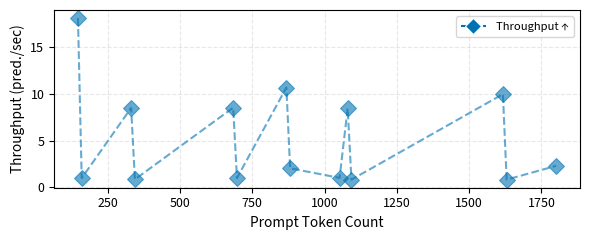

In [ ]:
fig, ax, df_grouped = plot_metrics_vs_prompt_token_count(
    df_metrics=df_metrics,
    items=items,
    figsize=(6, 2.5),
    metrics_to_plot=["throughput"],
    normalize_throughput=False,
    y_label="Throughput (pred./sec)",
    show_legend=False,
)